# Diana Dataset - Data Quality Checks

## 1. Import Libraries and Load Data

In [94]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('diana_dataset_binary.csv')
df['diabetes_label'] = df['diabetes_label'].astype(int)

print(f"Shape: {df.shape}")
df.head()

Shape: (1376, 22)


,SEQN,age,hba1c,fbs,bmi,total_cholesterol,ldl,hdl,triglycerides,systolic,...,family_history_diabetes,race_ethnicity,smoking_status,physical_activity,alcohol_use,cycle,diabetes_status,diabetes_label,menopausal_status,has_outlier
0,130396.0,56.0,5.0,104.0,27.3,214.0,124.0,68.0,108.5,122.0,...,0,3,1,1,0,2021-2023,Normal,0,Postmenopausal,False
1,130416.0,59.0,5.3,91.0,32.9,189.0,126.0,47.0,90.8,135.0,...,0,2,0,1,0,2021-2023,Normal,0,Postmenopausal,False
2,130599.0,54.0,6.1,99.0,50.2,184.0,125.0,41.0,172.2,99.0,...,0,2,1,1,0,2021-2023,Pre-diabetic,1,Postmenopausal,False
3,130662.0,52.0,5.5,94.0,30.9,191.0,119.0,53.0,73.9,128.0,...,1,4,1,1,0,2021-2023,Normal,0,Postmenopausal,False
4,130703.0,51.0,5.9,115.0,39.2,207.0,102.0,49.0,200.5,123.0,...,1,6,1,1,0,2021-2023,Pre-diabetic,1,Postmenopausal,False


## 2. Handling Duplicates

In [95]:
# Check for duplicate rows
duplicates = df.duplicated()
print(f"Number of duplicate rows: {duplicates.sum()}")

# Show duplicates if any
if duplicates.sum() > 0:
    print("\nDuplicate rows:")
    display(df[duplicates])

    # Drop duplicates
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"\nShape after dropping duplicates: {df.shape}")
else:
    print("No duplicate rows found.")

Number of duplicate rows: 0
No duplicate rows found.


## 3. Uniqueness

In [96]:
# Unique values per column
print("Unique values per column:\n")
print(df.nunique())

# Check if SEQN is a unique identifier
print(f"\nUnique SEQN values: {df['SEQN'].nunique()}")
print(f"SEQN is unique: {df['SEQN'].nunique() == len(df)}")

# Show duplicate SEQNs if any
dup_seqn = df['SEQN'].value_counts()
dup_seqn = dup_seqn[dup_seqn > 1]
if len(dup_seqn) > 0:
    print(f"\nDuplicate SEQN values:\n{dup_seqn}")
else:
    print("\nAll SEQN values are unique.")

Unique values per column:

SEQN                       1376
age                          16
hba1c                        72
fbs                         165
bmi                         511
total_cholesterol           238
ldl                         235
hdl                         119
triglycerides               504
systolic                    163
diastolic                   126
waist_circumference         589
family_history_diabetes       2
race_ethnicity                6
smoking_status                2
physical_activity             2
alcohol_use                   2
cycle                         6
diabetes_status               3
diabetes_label                3
menopausal_status             1
has_outlier                   2
dtype: int64

Unique SEQN values: 1376
SEQN is unique: True

All SEQN values are unique.


## 4. Missing Values

In [97]:
# Missing values count and percentage
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
})
missing = missing.sort_values('Missing %', ascending=False)
print("Missing Values Summary:\n")
display(missing)

Missing Values Summary:



,Missing Count,Missing %
SEQN,0,0.0
age,0,0.0
hba1c,0,0.0
fbs,0,0.0
bmi,0,0.0
total_cholesterol,0,0.0
ldl,0,0.0
hdl,0,0.0
triglycerides,0,0.0
systolic,0,0.0


## 5. Describe the Data

In [98]:
# Numeric summary
print("=== Numeric Columns ===\n")
display(df.describe())

# Categorical summary
print("\n=== Categorical Columns ===\n")
display(df.describe(include='object'))

# Data types
print("\n=== Data Types ===\n")
print(df.dtypes)

# General info
print("\n=== Dataset Info ===\n")
df.info()

=== Numeric Columns ===



,SEQN,age,hba1c,fbs,bmi,total_cholesterol,ldl,hdl,triglycerides,systolic,diastolic,waist_circumference,family_history_diabetes,race_ethnicity,smoking_status,physical_activity,alcohol_use,diabetes_label
count,1376.000000,1376.000000,1376.000000,1376.000000,1376.000000,1376.000000,1376.000000,1376.000000,1376.000000,1376.000000,1376.000000,1376.000000,1376.000000,1376.000000,1376.000000,1376.000000,1376.000000,1376.000000
mean,89910.114826,54.594477,5.973619,112.011628,31.089557,209.339634,125.667603,58.889270,124.625145,124.114462,73.476453,101.590196,0.477471,3.108285,0.436773,0.725291,0.053779,0.734738
std,26728.809436,4.108503,1.131677,37.639919,7.967761,42.153462,37.546085,16.587032,75.552945,18.064774,11.224603,16.700994,0.499674,1.232548,0.496167,0.446530,0.225663,0.773271
min,51661.000000,45.000000,4.100000,47.000000,13.600000,86.000000,24.000000,23.000000,24.000000,82.000000,30.000000,66.300000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,68902.000000,52.000000,5.400000,95.000000,25.490000,181.000000,101.000000,47.000000,77.000000,112.000000,66.000000,89.675000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
50%,85351.000000,55.000000,5.700000,102.000000,29.700000,207.000000,123.000000,56.000000,106.700000,122.000000,73.000000,100.100000,0.000000,3.000000,0.000000,1.000000,0.000000,1.000000
75%,100265.750000,58.000000,6.000000,112.000000,35.700000,234.000000,148.000000,67.250000,149.000000,134.000000,80.000000,112.200000,1.000000,4.000000,1.000000,1.000000,0.000000,1.000000
max,142288.000000,60.000000,14.200000,398.000000,74.800000,463.000000,375.000000,142.000000,876.000000,224.000000,134.000000,169.000000,1.000000,6.000000,1.000000,1.000000,1.000000,2.000000



=== Categorical Columns ===



,cycle,diabetes_status,menopausal_status
count,1376,1376,1376
unique,6,3,1
top,2021-2023,Normal,Postmenopausal
freq,265,642,1376



=== Data Types ===

SEQN                       float64
age                        float64
hba1c                      float64
fbs                        float64
bmi                        float64
total_cholesterol          float64
ldl                        float64
hdl                        float64
triglycerides              float64
systolic                   float64
diastolic                  float64
waist_circumference        float64
family_history_diabetes      int64
race_ethnicity               int64
smoking_status               int64
physical_activity            int64
alcohol_use                  int64
cycle                       object
diabetes_status             object
diabetes_label               int64
menopausal_status           object
has_outlier                   bool
dtype: object

=== Dataset Info ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1376 entries, 0 to 1375
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------

## 6. Dataset Purity - Entropy

Entropy measures the impurity/randomness in the dataset. An entropy of **0** means the dataset is perfectly pure (all samples belong to one class), while an entropy of **1** (for binary classification) means maximum impurity (equal split between classes).

In [99]:
from scipy.stats import entropy as scipy_entropy

target_col = 'diabetes_label'

# --- Dataset-level entropy (target variable) ---
target_counts = df[target_col].value_counts(normalize=True)
dataset_entropy = scipy_entropy(target_counts, base=2)

print("="*50)
print("  Dataset Purity Check (Target Entropy)")
print("="*50)
print(f"\nTarget column: {target_col}")
print(f"Class distribution:\n{df[target_col].value_counts()}")
print(f"\nClass proportions:\n{target_counts.round(4)}")
print(f"\nDataset Entropy (base-2): {dataset_entropy:.4f}")

if dataset_entropy == 0:
    print("Interpretation: Dataset is perfectly PURE (single class).")
elif dataset_entropy < 0.5:
    print("Interpretation: Dataset is relatively PURE (dominated by one class).")
elif dataset_entropy < 0.9:
    print("Interpretation: Dataset has MODERATE impurity.")
else:
    print("Interpretation: Dataset has HIGH impurity (near-equal class distribution).")

# --- Per-feature entropy (for categorical / binary columns) ---
print("\n" + "="*50)
print("  Per-Feature Entropy")
print("="*50 + "\n")

feature_entropies = {}
for col in df.columns:
    if col in [target_col, 'SEQN', 'cycle', 'diabetes_status']:
        continue
    val_counts = df[col].value_counts(normalize=True, dropna=True)
    feat_ent = scipy_entropy(val_counts, base=2)
    feature_entropies[col] = feat_ent

ent_df = pd.DataFrame.from_dict(feature_entropies, orient='index', columns=['Entropy'])
ent_df = ent_df.sort_values('Entropy', ascending=False)
display(ent_df.style.format({'Entropy': '{:.4f}'}).background_gradient(cmap='YlOrRd'))

  Dataset Purity Check (Target Entropy)

Target column: diabetes_label
Class distribution:
diabetes_label
0    642
1    457
2    277
Name: count, dtype: int64

Class proportions:
diabetes_label
0    0.4666
1    0.3321
2    0.2013
Name: proportion, dtype: float64

Dataset Entropy (base-2): 1.5068
Interpretation: Dataset has HIGH impurity (near-equal class distribution).

  Per-Feature Entropy



,Entropy
waist_circumference,8.8898
bmi,8.5005
triglycerides,8.3589
total_cholesterol,7.3576
ldl,7.2765
fbs,6.0380
hdl,6.0199
systolic,5.9041
diastolic,5.3312
hba1c,4.6588


## 7. Information Gain (Entropy-Based)

Information Gain measures how much a feature reduces the entropy of the target variable. Higher information gain means the feature is more useful for predicting the target.

$$IG(T, A) = H(T) - H(T|A) = H(T) - \sum_{v \in A} \frac{|S_v|}{|S|} \cdot H(S_v)$$

  Information Gain (Entropy) Rankings



,Information Gain
hba1c,1.1815
fbs,0.4134
hdl,0.0973
waist_circumference,0.0912
bmi,0.0829
triglycerides,0.0735
total_cholesterol,0.0416
ldl,0.0412
systolic,0.0367
race_ethnicity,0.0300


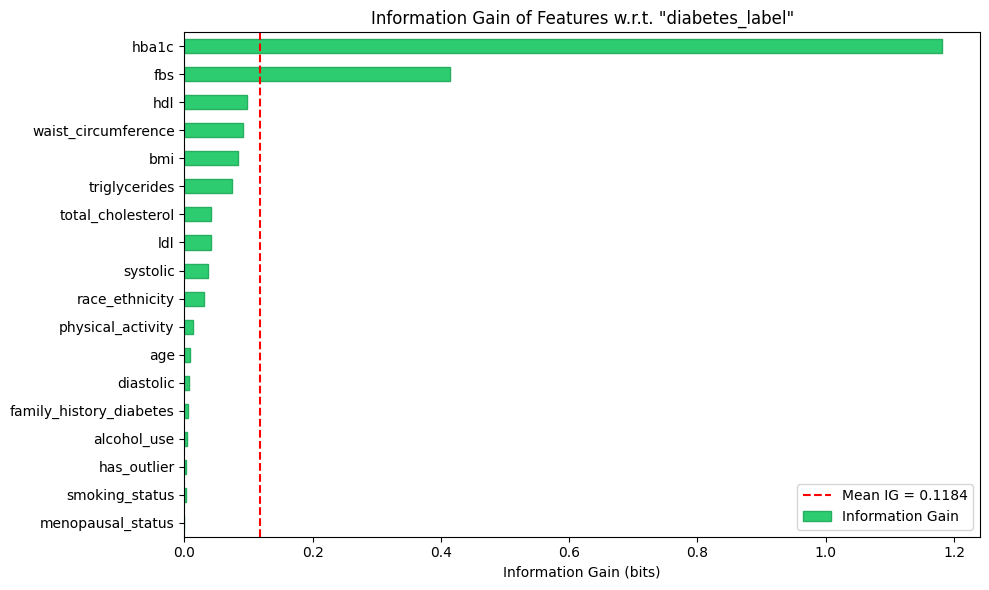

In [100]:
import matplotlib.pyplot as plt

def calc_entropy(series):
    """Calculate entropy (base 2) of a pandas Series."""
    probs = series.value_counts(normalize=True, dropna=True)
    return scipy_entropy(probs, base=2)

def information_gain(df, feature, target):
    """Calculate information gain of a feature w.r.t. the target."""
    # Overall entropy of the target
    total_entropy = calc_entropy(df[target])

    # Weighted entropy after splitting on the feature
    values = df[feature].dropna().unique()
    weighted_entropy = 0
    total_count = df[feature].dropna().shape[0]

    for val in values:
        subset = df[df[feature] == val]
        weight = len(subset) / total_count
        weighted_entropy += weight * calc_entropy(subset[target])

    return total_entropy - weighted_entropy

# --- Compute Information Gain for all features ---
feature_cols = [c for c in df.columns if c not in [target_col, 'SEQN', 'cycle', 'diabetes_status']]

# For continuous features, bin them into quantile-based groups
ig_results = {}
for col in feature_cols:
    if df[col].nunique() > 10:
        # Continuous: discretize into 10 quantile bins
        binned = pd.qcut(df[col], q=10, duplicates='drop')
        temp_df = df[[target_col]].copy()
        temp_df[col] = binned
        ig_results[col] = information_gain(temp_df, col, target_col)
    else:
        # Categorical / binary: use as-is
        ig_results[col] = information_gain(df, col, target_col)

ig_df = pd.DataFrame.from_dict(ig_results, orient='index', columns=['Information Gain'])
ig_df = ig_df.sort_values('Information Gain', ascending=False)

print("="*50)
print("  Information Gain (Entropy) Rankings")
print("="*50 + "\n")
display(ig_df.style.format({'Information Gain': '{:.4f}'}).background_gradient(cmap='Greens'))

# --- Bar plot ---
fig, ax = plt.subplots(figsize=(10, 6))
ig_df.sort_values('Information Gain').plot.barh(ax=ax, legend=False, color='#2ecc71', edgecolor='#27ae60')
ax.set_xlabel('Information Gain (bits)')
ax.set_title(f'Information Gain of Features w.r.t. "{target_col}"')
ax.axvline(x=ig_df['Information Gain'].mean(), color='red', linestyle='--', label=f"Mean IG = {ig_df['Information Gain'].mean():.4f}")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Distribution Plot for BMI

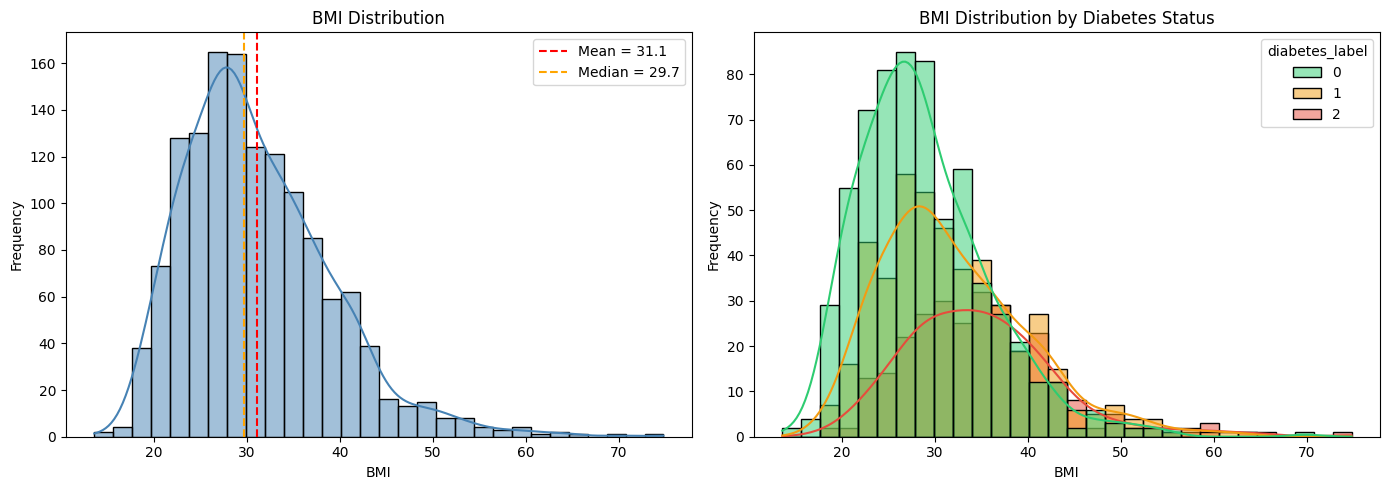

In [101]:
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram + KDE
sns.histplot(df['bmi'], kde=True, bins=30, color='steelblue', ax=axes[0])
axes[0].set_title('BMI Distribution')
axes[0].set_xlabel('BMI')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['bmi'].mean(), color='red', linestyle='--', label=f"Mean = {df['bmi'].mean():.1f}")
axes[0].axvline(df['bmi'].median(), color='orange', linestyle='--', label=f"Median = {df['bmi'].median():.1f}")
axes[0].legend()

# BMI distribution by diabetes status
sns.histplot(data=df, x='bmi', hue='diabetes_label', kde=True, bins=30, ax=axes[1],
             palette=['#2ecc71', '#f39c12', '#e74c3c'], hue_order=[0, 1, 2])
axes[1].set_title('BMI Distribution by Diabetes Status')
axes[1].set_xlabel('BMI')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## 9. Count Plots for Binary Variables

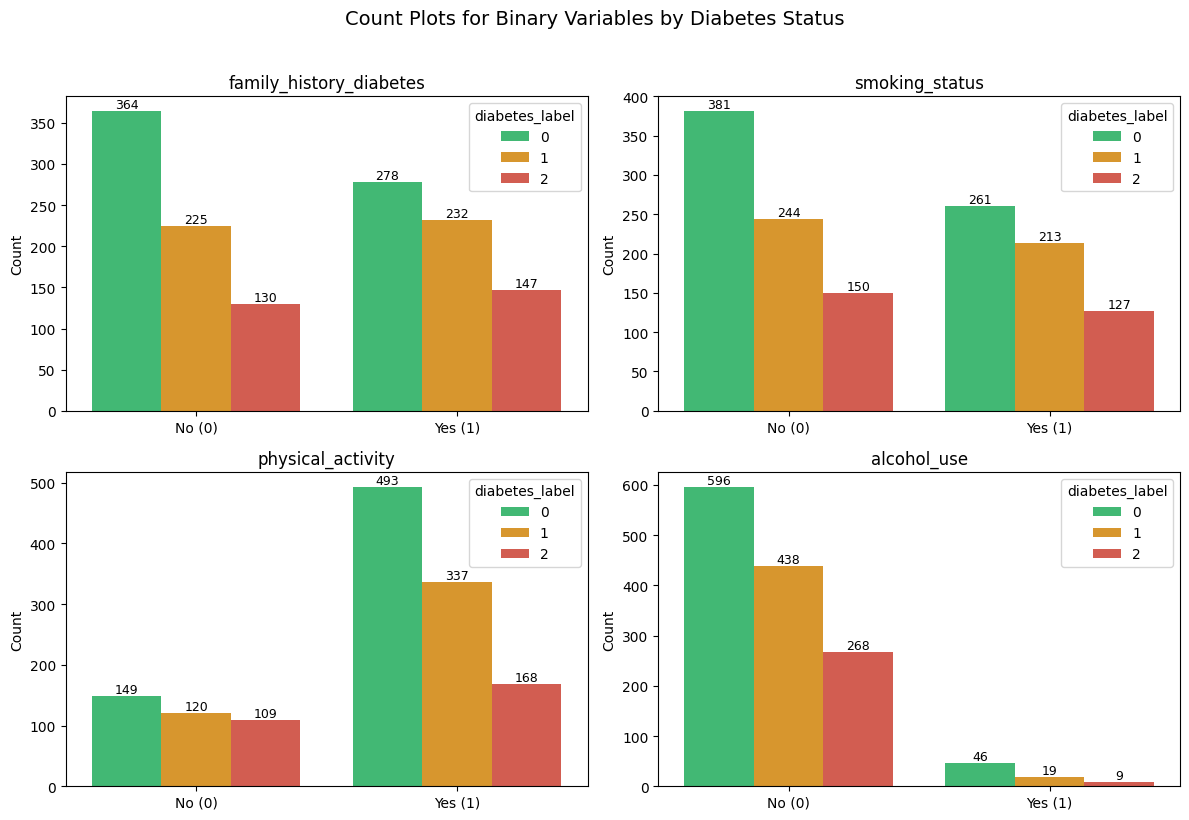

In [102]:
binary_cols = ['family_history_diabetes', 'smoking_status', 'physical_activity', 'alcohol_use']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(binary_cols):
    sns.countplot(data=df, x=col, hue='diabetes_label', ax=axes[i],
                  palette=['#2ecc71', '#f39c12', '#e74c3c'], hue_order=[0, 1, 2])
    axes[i].set_title(f'{col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['No (0)', 'Yes (1)'])

    # Add count labels on bars
    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%d', fontsize=9)

plt.suptitle('Count Plots for Binary Variables by Diabetes Status', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 10. Pair Plot for Numeric Features

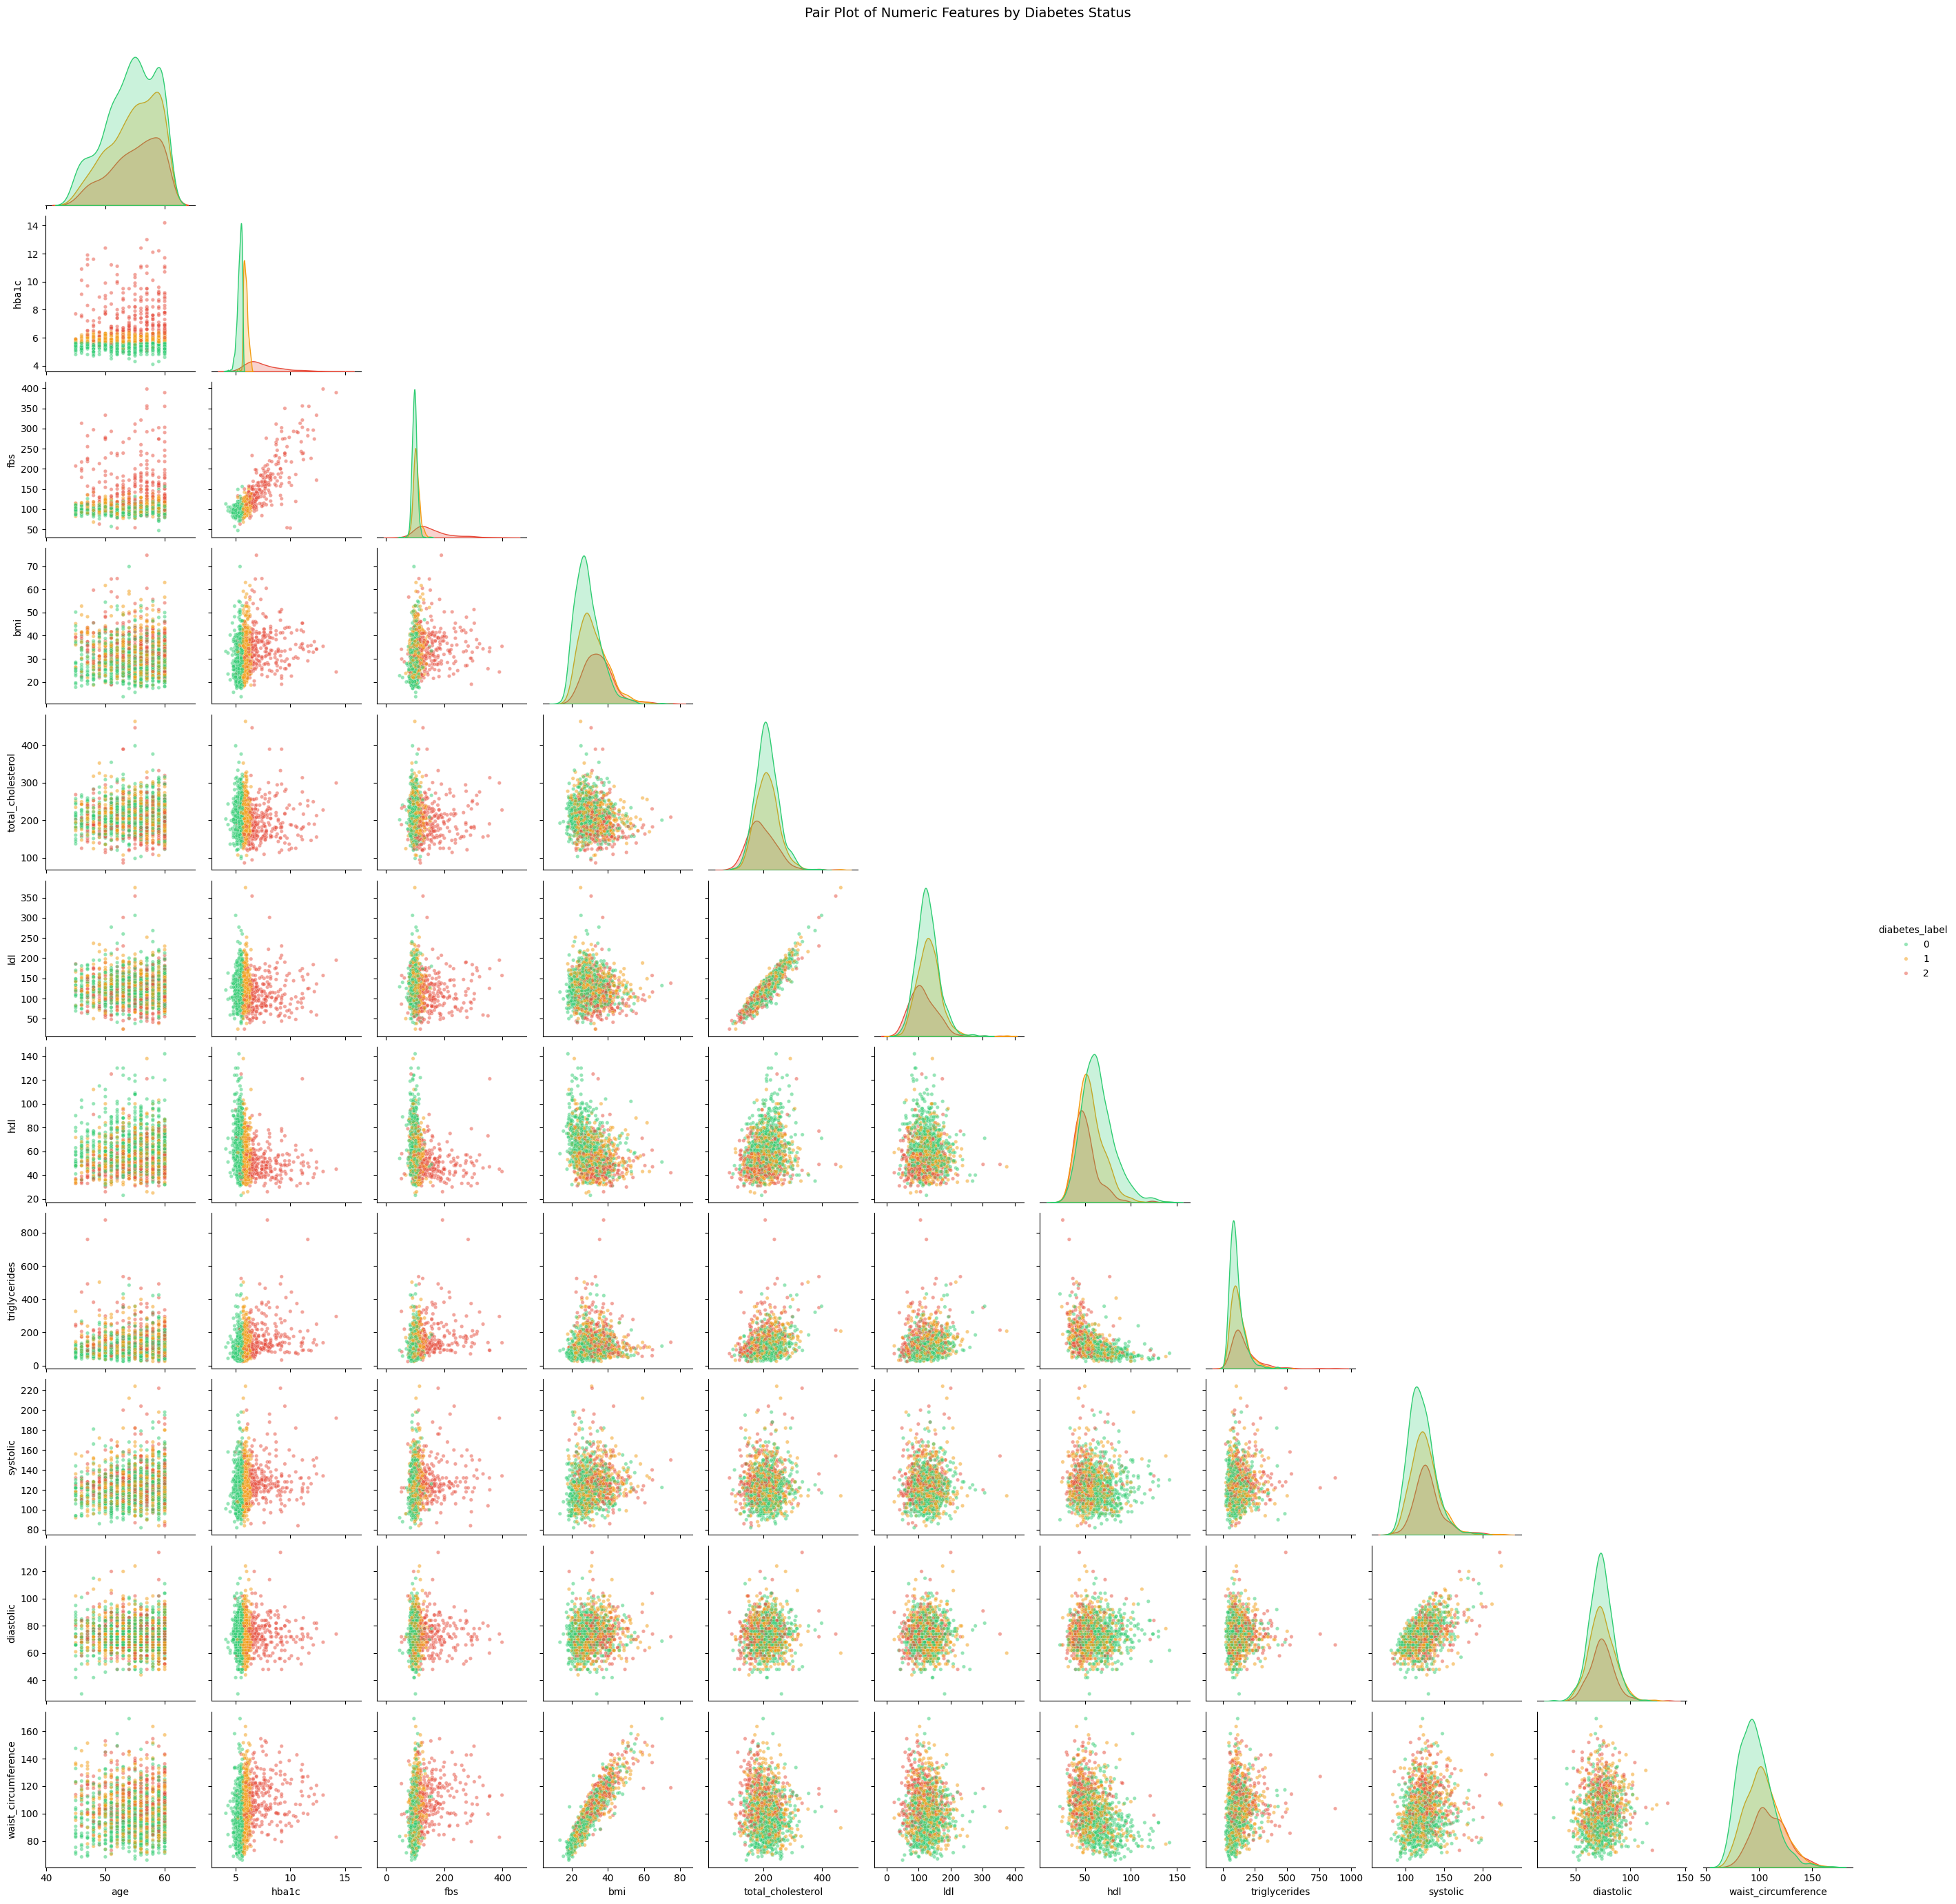

In [103]:
# Select key numeric features for the pair plot
numeric_features = ['age', 'hba1c', 'fbs', 'bmi', 'total_cholesterol', 'ldl', 'hdl', 'triglycerides',
                    'systolic', 'diastolic', 'waist_circumference']

pair_plot = sns.pairplot(
    df[numeric_features + ['diabetes_label']],
    hue='diabetes_label',
    palette=['#2ecc71', '#f39c12', '#e74c3c'],
    hue_order=[0, 1, 2],
    diag_kind='kde',
    plot_kws={'alpha': 0.5, 's': 15},
    corner=True
)
pair_plot.figure.suptitle('Pair Plot of Numeric Features by Diabetes Status', y=1.01, fontsize=14)
plt.show()

## 11. Multivariate Analysis

Exploring relationships between multiple features simultaneously, grouped by diabetes status.

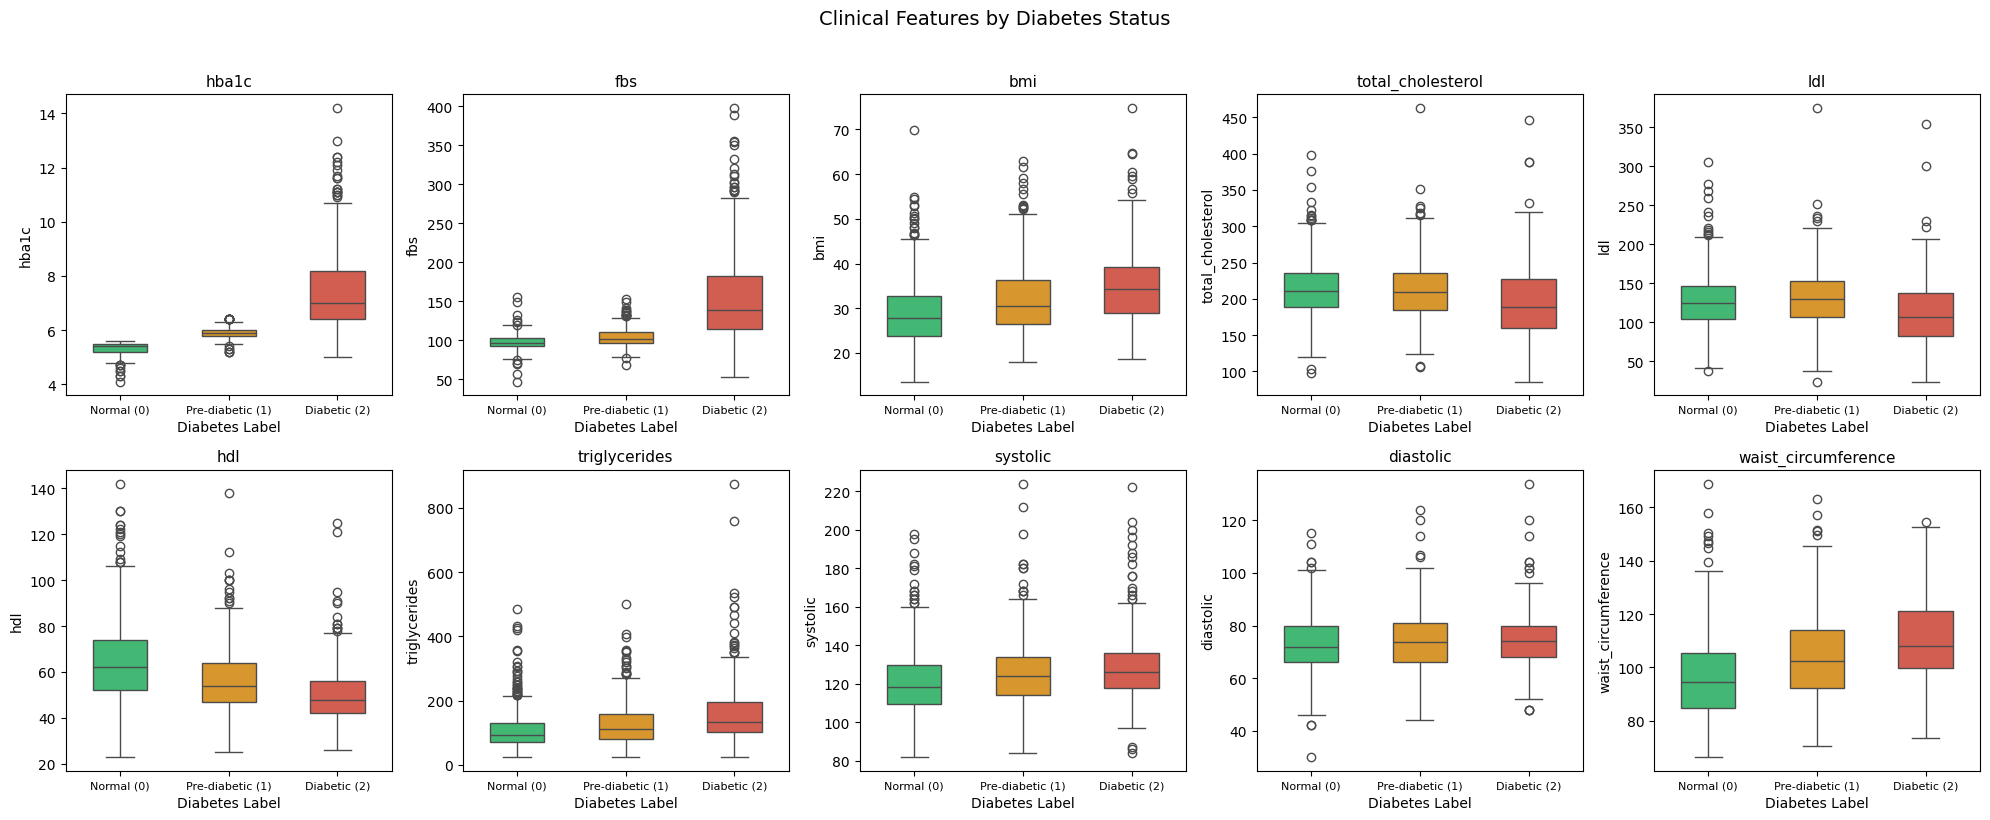

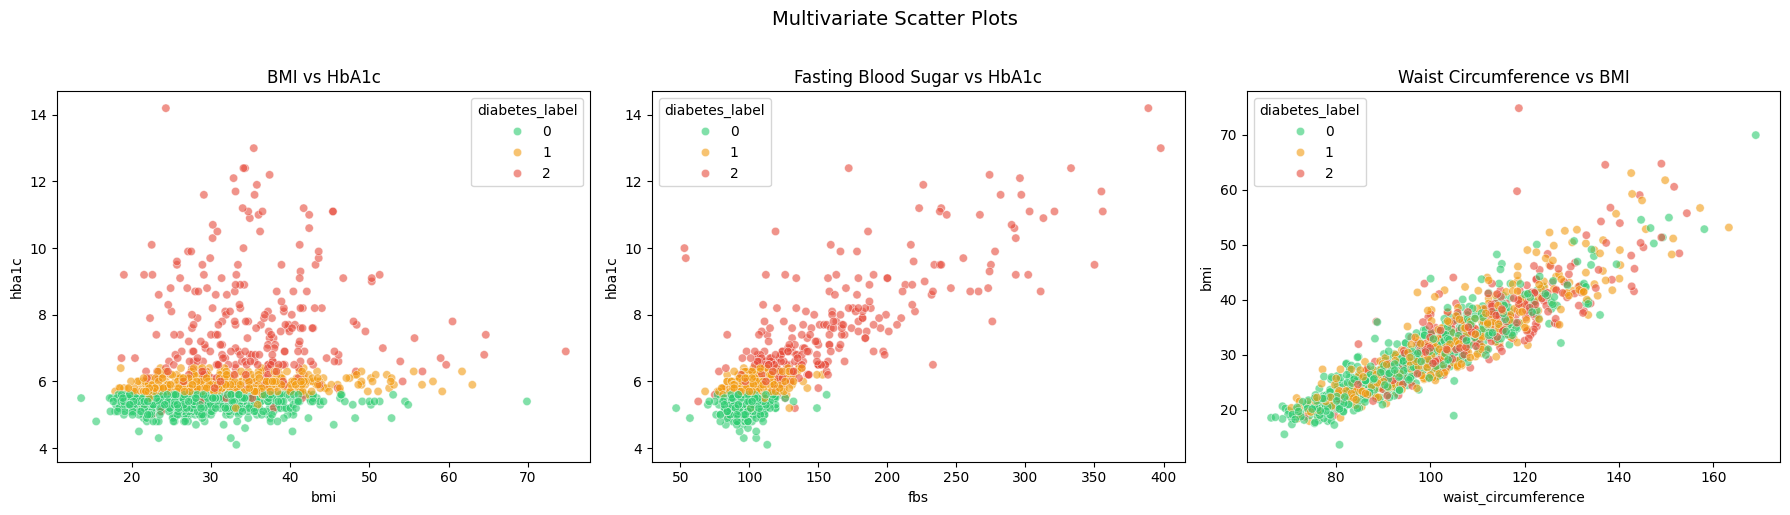

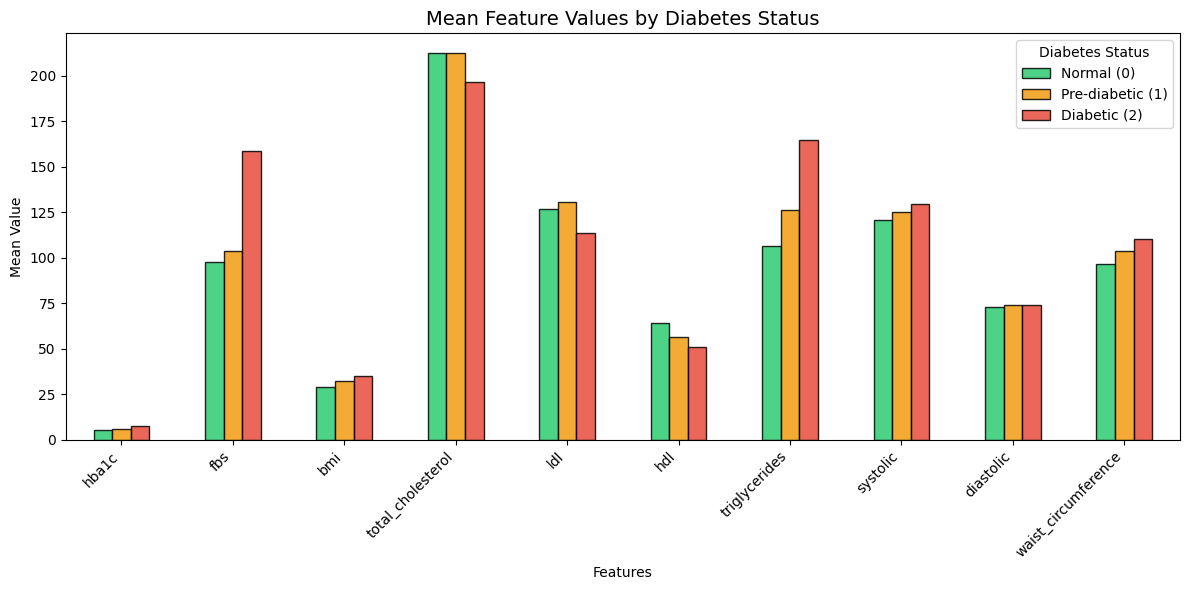

In [104]:
# --- 11a. Box plots of key clinical features by diabetes status ---
clinical_features = ['hba1c', 'fbs', 'bmi', 'total_cholesterol', 'ldl', 'hdl',
                     'triglycerides', 'systolic', 'diastolic', 'waist_circumference']

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(clinical_features):
    sns.boxplot(data=df, x='diabetes_label', y=col, hue='diabetes_label', ax=axes[i],
                palette=['#2ecc71', '#f39c12', '#e74c3c'], order=[0, 1, 2], hue_order=[0, 1, 2],
                width=0.5, legend=False)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('Diabetes Label')
    axes[i].set_xticks([0, 1, 2])
    axes[i].set_xticklabels(['Normal (0)', 'Pre-diabetic (1)', 'Diabetic (2)'], fontsize=8)

plt.suptitle('Clinical Features by Diabetes Status', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# --- 11b. Scatter plots: key interactions ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# BMI vs HbA1c
sns.scatterplot(data=df, x='bmi', y='hba1c', hue='diabetes_label',
                palette=['#2ecc71', '#f39c12', '#e74c3c'], hue_order=[0, 1, 2], alpha=0.6, ax=axes[0])
axes[0].set_title('BMI vs HbA1c')

# FBS vs HbA1c
sns.scatterplot(data=df, x='fbs', y='hba1c', hue='diabetes_label',
                palette=['#2ecc71', '#f39c12', '#e74c3c'], hue_order=[0, 1, 2], alpha=0.6, ax=axes[1])
axes[1].set_title('Fasting Blood Sugar vs HbA1c')

# Waist Circumference vs BMI
sns.scatterplot(data=df, x='waist_circumference', y='bmi', hue='diabetes_label',
                palette=['#2ecc71', '#f39c12', '#e74c3c'], hue_order=[0, 1, 2], alpha=0.6, ax=axes[2])
axes[2].set_title('Waist Circumference vs BMI')

plt.suptitle('Multivariate Scatter Plots', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# --- 11c. Grouped bar chart: mean feature values by diabetes status ---
mean_by_diabetes = df[clinical_features + ['diabetes_label']].groupby('diabetes_label').mean()
mean_normalized = mean_by_diabetes.T
mean_normalized.columns = ['Normal (0)', 'Pre-diabetic (1)', 'Diabetic (2)']

fig, ax = plt.subplots(figsize=(12, 6))
mean_normalized.plot.bar(ax=ax, color=['#2ecc71', '#f39c12', '#e74c3c'], edgecolor='black', alpha=0.85)
ax.set_title('Mean Feature Values by Diabetes Status', fontsize=14)
ax.set_xlabel('Features')
ax.set_ylabel('Mean Value')
ax.legend(title='Diabetes Status')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

## 12. Count Plot for Diabetes Label

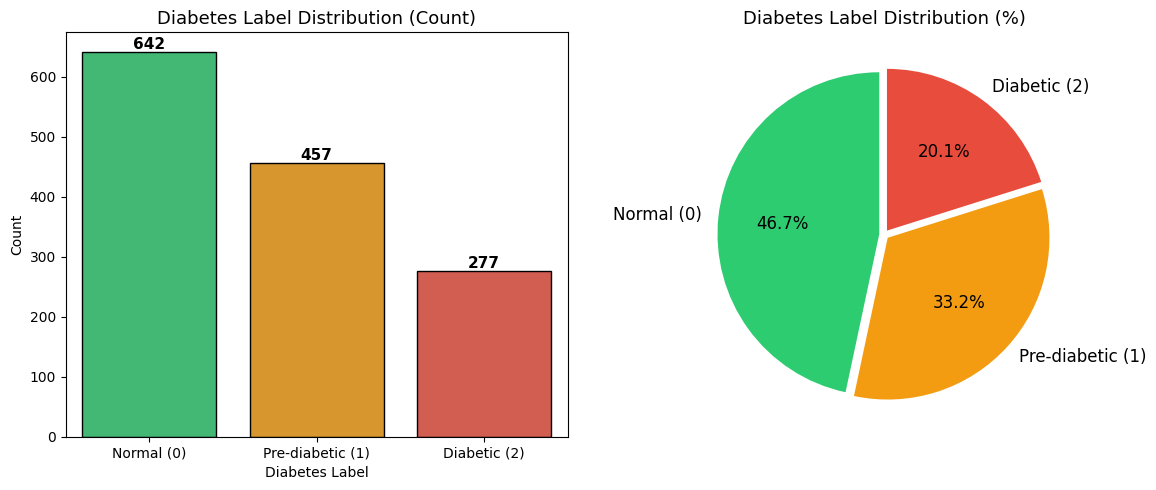

In [105]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
counts = df['diabetes_label'].value_counts()
sns.countplot(data=df, x='diabetes_label', hue='diabetes_label', ax=axes[0],
              palette=['#2ecc71', '#f39c12', '#e74c3c'],
              order=[0, 1, 2], hue_order=[0, 1, 2], edgecolor='black', legend=False)
axes[0].set_title('Diabetes Label Distribution (Count)', fontsize=13)
axes[0].set_xlabel('Diabetes Label')
axes[0].set_ylabel('Count')
axes[0].set_xticks([0, 1, 2])
axes[0].set_xticklabels(['Normal (0)', 'Pre-diabetic (1)', 'Diabetic (2)'])
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%d', fontsize=11, fontweight='bold')

# Pie chart
axes[1].pie(counts, labels=['Normal (0)', 'Pre-diabetic (1)', 'Diabetic (2)'],
            colors=['#2ecc71', '#f39c12', '#e74c3c'], autopct='%1.1f%%',
            startangle=90, explode=(0.03, 0.03, 0.03), textprops={'fontsize': 12})
axes[1].set_title('Diabetes Label Distribution (%)', fontsize=13)

plt.tight_layout()
plt.show()

## 13. Correlation Matrix

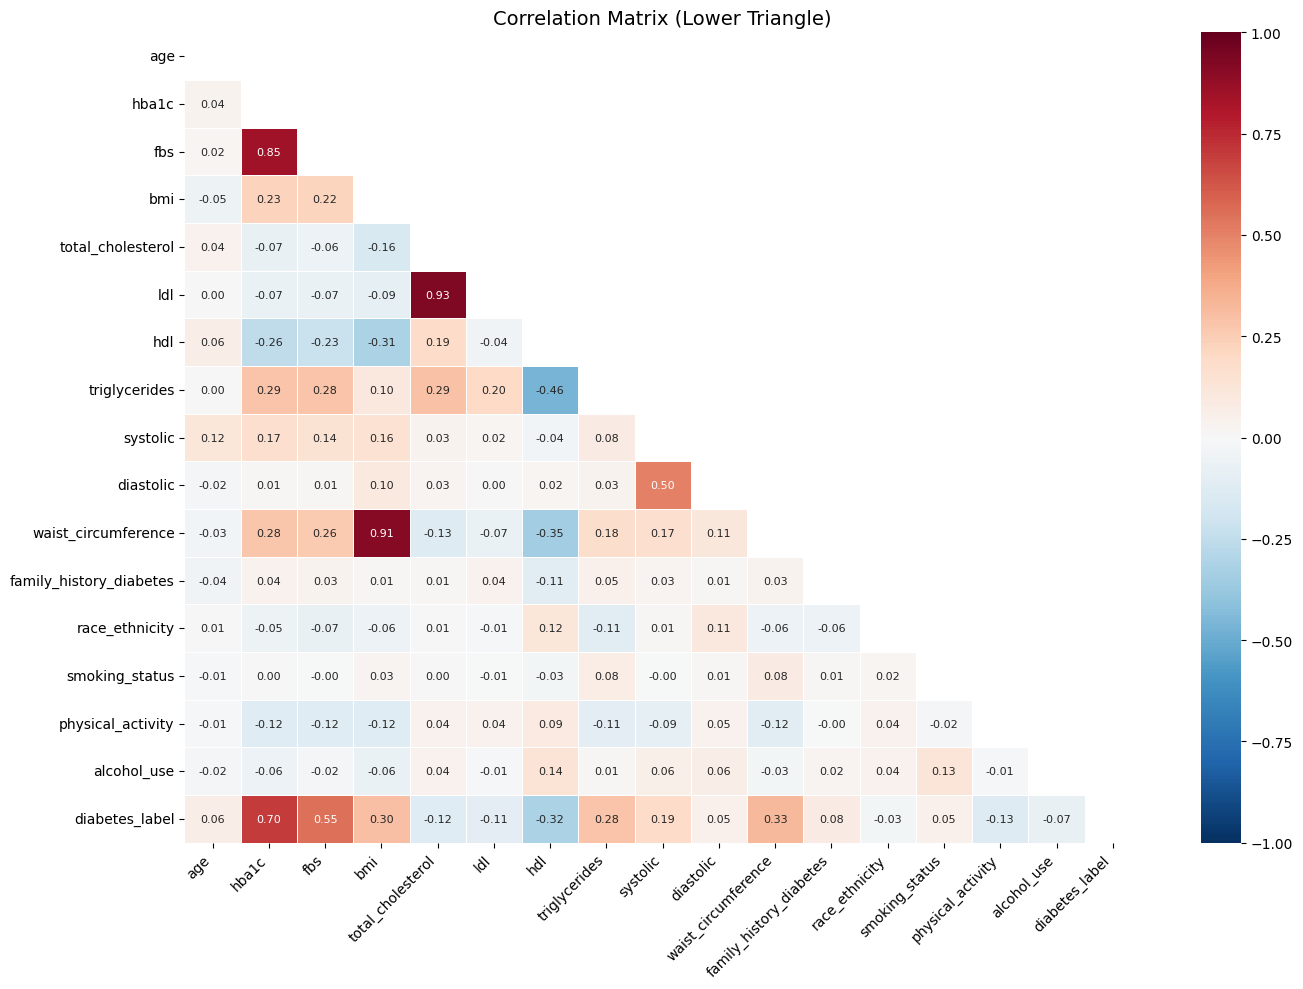

Top 10 Positive Correlations:



Top 10 Negative Correlations:


In [106]:
# Select numeric columns for correlation
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Exclude SEQN (identifier)
numeric_cols = [c for c in numeric_cols if c != 'SEQN']

corr_matrix = df[numeric_cols].corr()

# Full correlation heatmap
fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Correlation Matrix (Lower Triangle)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Display top positive and negative correlations
corr_pairs = corr_matrix.unstack()
corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) != corr_pairs.index.get_level_values(1)]
corr_pairs = corr_pairs.drop_duplicates().sort_values(ascending=False)

print("Top 10 Positive Correlations:")
display(corr_pairs.head(10).to_frame('Correlation').style.format({'Correlation': '{:.4f}'}))

print("\nTop 10 Negative Correlations:")
display(corr_pairs.tail(10).to_frame('Correlation').style.format({'Correlation': '{:.4f}'}))

## 14. Heatmap of Correlations with Target Column

Focused view showing how each feature correlates with `diabetes_label`.

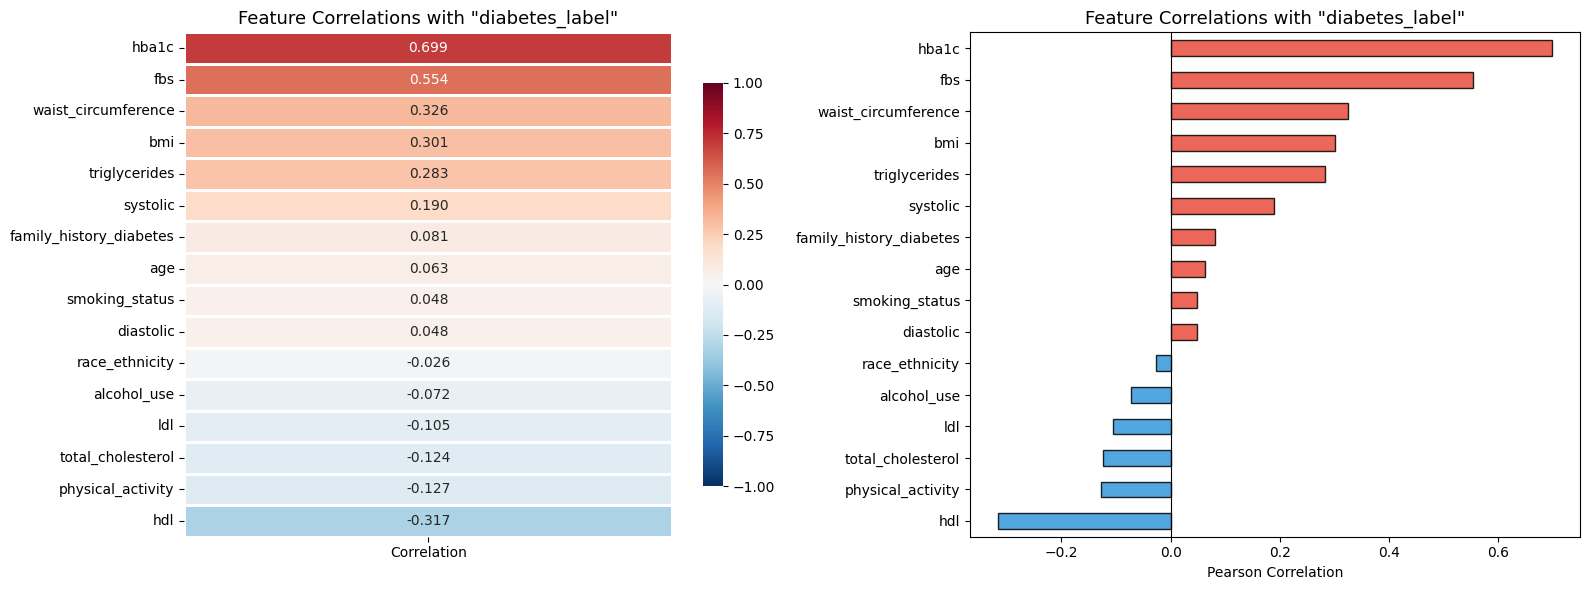


Strongest positive correlations with diabetes_label:
  hba1c: 0.6994
  fbs: 0.5535
  waist_circumference: 0.3257

Strongest negative correlations with diabetes_label:
  total_cholesterol: -0.1237
  physical_activity: -0.1269
  hdl: -0.3167


In [107]:
# Correlation of all numeric features with the target
target_corr = corr_matrix['diabetes_label'].drop('diabetes_label').sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap style
target_corr_df = target_corr.to_frame('Correlation')
sns.heatmap(target_corr_df, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, linewidths=1, ax=axes[0], cbar_kws={'shrink': 0.8})
axes[0].set_title(f'Feature Correlations with "{target_col}"', fontsize=13)
axes[0].set_ylabel('')

# Horizontal bar chart
colors = ['#e74c3c' if v > 0 else '#3498db' for v in target_corr.values]
target_corr.sort_values().plot.barh(ax=axes[1], color=colors[::-1], edgecolor='black', alpha=0.85)
axes[1].set_title(f'Feature Correlations with "{target_col}"', fontsize=13)
axes[1].set_xlabel('Pearson Correlation')
axes[1].axvline(x=0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

# Print summary
print(f"\nStrongest positive correlations with {target_col}:")
for feat, val in target_corr.head(3).items():
    print(f"  {feat}: {val:.4f}")

print(f"\nStrongest negative correlations with {target_col}:")
for feat, val in target_corr.tail(3).items():
    print(f"  {feat}: {val:.4f}")